# 2.2 파이토치 기본 문법

## 1) 텐서 다루기

In [ ]:
import torch
print(torch.tensor([[1,2],[3,4]]))
print(torch.tensor([[1,2],[3,4]],device='cuda:0'))
print(torch.tensor([[1,2],[3,4]],dtype=torch.float64))

tensor([[1, 2],
        [3, 4]])
tensor([[1, 2],
        [3, 4]], device='cuda:0')
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)


In [ ]:
temp=torch.tensor([[1,2],[3,4]])
print(temp.numpy())

temp=torch.tensor([[1,2],[3,4]],device='cuda:0')
print(temp.to('cpu').numpy())

[[1 2]
 [3 4]]
[[1 2]
 [3 4]]


In [ ]:
temp=torch.FloatTensor([1,2,3,4,5,6,7])
print(temp[0],temp[1],temp[-1])
print('------------------')
print(temp[2:5],temp[4:-1])

tensor(1.) tensor(2.) tensor(7.)
--------------
tensor([3., 4., 5.]) tensor([5., 6.])


In [ ]:
v=torch.tensor([1,2,3])
w=torch.tensor([3,4,6])
print(w-v)

tensor([2, 2, 3])


In [ ]:
temp=torch.tensor([[1,2],[3,4]])
print(temp.shape)
print('------------------')
print(temp.view(4,1))
print('------------------')
print(temp.view(-1))
print('------------------')
print(temp.view(1,-1))
print('------------------')
print(temp.view(-1,1))

torch.Size([2, 2])
------------------
tensor([[1],
        [2],
        [3],
        [4]])
------------------
tensor([1, 2, 3, 4])
------------------
tensor([[1, 2, 3, 4]])
------------------
tensor([[1],
        [2],
        [3],
        [4]])


## 2) 데이터 준비



```
import pandas as pd
import torch

data=pd.read_csv('.../class2.csv')
x=torch.from_numpy(data['x'].values).unsqeeze(dim=1).float()
y=torch.from_numpy(data['y'].values).unsqeeze(dim=1).float()

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class CustomDataset(Dataset):
    def __init__(self, csv_file):
        self.label=pd.read_csv(csv_file)

    def __len__(self):
        return len(self.label)

    def __getitem__(self,idx):
        sample=torch.tensor(self.label.iloc[idx,0:3]).int()
        label=torch.tensor(self.label.iloc[idx,3]).int()
        return sample,label

tensor_dataset=CustomDataset('.../covtype.csv')
dataset=DataLoader(tensor_dataset, batch_size=4, shuffle=True)
```



In [1]:
import torchvision.transforms as transforms

mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, ), (1.0,))
]) #평균이 0.5, 표준편차가 1.0이 되도록 데이터의 분포를 조정

from torchvision.datasets import MNIST
import requests
download_root = '../chap02/data/MNIST_DATASET'

train_dataset = MNIST(download_root, transform = mnist_transform, train=True, download = True)
valid_dataset = MNIST(download_root, transform = mnist_transform, train= False, download = True)
test_dataset  = MNIST(download_root, transform = mnist_transform, train= False, download = True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 513kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.59MB/s]


## 3) 모델 정의

단순 신경망 정의
```
model=nn.Linear(in_features=1, out_features=1, bias=True)
```



모듈 상속하여 정의
```
class MLP(Module):
    def __init__(self,inputs):
        super(MLP,self).__init__()
        self.layer=Linear(inputs,1)
        self.activation=Sigmoid()
    def forward(self,X):
        X=self.layer(X)
        X=self.activation(X)
        return X
```



Sequential 신경망 정의

In [4]:
import torch.nn as nn
class MLP(nn.Module):
  def __init__(self):
    super(MLP, self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels = 64, kernel_size = 5),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(2)
    )

    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=64, out_channels = 630, kernel_size = 5),
        nn.ReLU(inplace = True),
        nn.MaxPool2d(2)
    )
    self.layer3 = nn.Sequential(
        nn.Linear(in_features = 30*5*5, out_features = 10, bias = True),
        nn.ReLU(inplace = True),
    )

    def forward(self, x):
      x = self.layer1(x)
      x = self.layer2(x)
      x = x.view(x.shape[0], -1)
      x = self.layer3(x)
      return x
model = MLP()

print("Printing children\n--------------------------")
print(list(model.children()))
print("\n\nPrinting Modules\n-----------------------")
print(list(model.modules()))

Printing children
--------------------------
[Sequential(
  (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Conv2d(64, 630, kernel_size=(5, 5), stride=(1, 1))
  (1): ReLU(inplace=True)
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
), Sequential(
  (0): Linear(in_features=750, out_features=10, bias=True)
  (1): ReLU(inplace=True)
)]


Printing Modules
-----------------------
[MLP(
  (layer1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(64, 630, kernel_size=(5, 5), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer3): Sequential(
    (0): Linear(in_feat

함수로 신경망 정의
```
def MLP(in_features = 1, hidden_features =20, out_features =1):
  hidden = nn.Linear(in_features = in_features, out_features=hidden_features, bias=True)
  activation = nn.ReLU()
  output = nn.Linear(in_features = hidden_features, out_features = out_features, bias = True)
  net = nn.Sequential(hidden, activation, output)
  return net
```

## 4) 파라미터 정의



```
from torch.optim import optimizer
criterion=torch.nn.MSELoss()
optimizer=torch.optim.SGD(model.parameters(),lr=0.01, momentum=0.9)
scheduler=torch.optim.lr_scheduler.LambdaLR(optimizer=optimizer,lr_lambda=lambda epoch:0.95**epoch)

for epoch in range(1,100+1):
    for x,y in dataloader:
        optimizer.zero_grad()
loss_fn(model(x),y).backward()
optimizer.step()
scheduler.step()
```



## 5) 모델 훈련



```
for epoch in range(100):
    yhat=model(x_train)
    loss=criterion(yhat,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
```



## 6) 모델 평가

함수를 이용해  모델을 평가


```
import torch
import torchmetrics

preds = torch.randn(10,5).softmax(dim=-1)
target = torch.randint(5,(10,))

acc = torchmetrics.functional.accuracy(preds, target)
```



모듈을 이용해 모델을 평가


```
import torch
import torchmetrics

metric = torchmetrics.Accuracy() #모델 평가 초기화

n_batches = 10
for i in range(n_batches):
  preds = torch.randn(10,5).softmax(dim=-1)
  target = torch.randint(5,(10,))

  acc = metric(preds, target)
  print(F"Accuracy on batch {i} :{acc}") #현재 배치에서 모델 평가

acc = metric.compute()
print(f"Accuracy on all datat: {acc}") #모든 배치에서 모델 평가
```



## 7) 훈련 과정 모니터링



```
import torch
from torch.utils.tensorboard import SummaryWriter
writer=SummaryWriter('저장될 위치')

for epoch in range(num_epochs):
    model.train()
    batch_loss=0.0

    for i, (x,y) in enumerate(dataloader):
        x,y=x.to(device).float(), y.to(device).float()
        outputs=model(x)
        loss=criterion(outputs,y)
        writer.add_scalar('Loss',loss,epoch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
writer.close()
```



In [8]:
!tensorboard --logdir ../chap02/tensorboard --port 6006

/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:292: SyntaxWarning: invalid escape sequence '\s'
  "[`\000-\040\177-\240\s]+",
/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:339: SyntaxWarning: invalid escape sequence '\s'
  style = re.compile('url\s*\(\s*[^\s)]+?\s*\)\s*').sub(' ', style)
/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:354: SyntaxWarning: invalid escape sequence '\s'
  if not re.match("^\s*([-\w]+\s*:[^:;]*(;\s*|$))*$", style):
/usr/local/lib/python3.12/dist-packages/tensorboard/_vendor/bleach/sanitizer.py:358: SyntaxWarning: invalid escape sequence '\w'
  for prop, value in re.findall('([-\w]+)\s*:\s*([^:;]*)', style):
2026-03-09 03:39:49.736340: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773027589.773334    5495 cuda_dnn.

# 2.4 파이토치 코드 맛보기

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
directory_path = '/content/gdrive/My Drive/Colab Notebooks/Euron/데이터/'
dataset = pd.read_csv(directory_path+'car_evaluation.csv')

Mounted at /content/gdrive


In [ ]:
dataset.head()

,price,maint,doors,persons,lug_capacity,safety,output
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


<Axes: ylabel='count'>

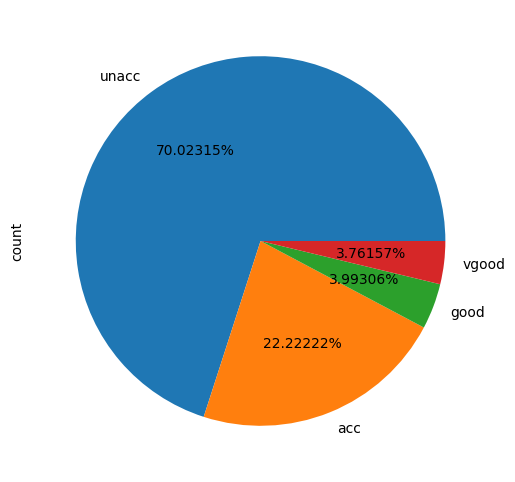

In [ ]:
fig_size=plt.rcParams['figure.figsize']
fig_size[0]=8
fig_size[1]=6
plt.rcParams['figure.figsize']=fig_size
dataset.output.value_counts().plot(kind='pie',autopct='%0.05f%%')

In [ ]:
categorical_columns=['price','maint','doors','persons','lug_capacity','safety']
for category in categorical_columns:
    dataset[category]=dataset[category].astype('category')

price=dataset['price'].cat.codes.values
maint=dataset['maint'].cat.codes.values
doors=dataset['doors'].cat.codes.values
persons=dataset['persons'].cat.codes.values
lug_capacity=dataset['lug_capacity'].cat.codes.values
safety=dataset['safety'].cat.codes.values

categorical_data=np.stack([price,maint,doors,persons,lug_capacity,safety],1)
categorical_data[:10]


array([[3, 3, 0, 0, 2, 1],
       [3, 3, 0, 0, 2, 2],
       [3, 3, 0, 0, 2, 0],
       [3, 3, 0, 0, 1, 1],
       [3, 3, 0, 0, 1, 2],
       [3, 3, 0, 0, 1, 0],
       [3, 3, 0, 0, 0, 1],
       [3, 3, 0, 0, 0, 2],
       [3, 3, 0, 0, 0, 0],
       [3, 3, 0, 1, 2, 1]], dtype=int8)

In [ ]:
categorical_data=torch.tensor(categorical_data,dtype=torch.int64)
categorical_data[:10]

tensor([[3, 3, 0, 0, 2, 1],
        [3, 3, 0, 0, 2, 2],
        [3, 3, 0, 0, 2, 0],
        [3, 3, 0, 0, 1, 1],
        [3, 3, 0, 0, 1, 2],
        [3, 3, 0, 0, 1, 0],
        [3, 3, 0, 0, 0, 1],
        [3, 3, 0, 0, 0, 2],
        [3, 3, 0, 0, 0, 0],
        [3, 3, 0, 1, 2, 1]])

In [ ]:
outputs=pd.get_dummies(dataset.output)
outputs=outputs.values
outputs=torch.tensor(outputs).flatten()

print(categorical_data.shape)
print(outputs.shape)

torch.Size([1728, 6])
torch.Size([6912])


In [ ]:
categorical_column_sizes=[len(dataset[column].cat.categories) for column in categorical_columns]
categorical_embedding_sizes=[(col_size,min(50,(col_size+1)//2)) for col_size in categorical_column_sizes]
print(categorical_embedding_sizes)

[(4, 2), (4, 2), (4, 2), (3, 2), (3, 2), (3, 2)]


In [ ]:
total_records=1728
test_records=int(total_records*.2)

categorical_train_data=categorical_data[:total_records-test_records]
categorical_test_data=categorical_data[total_records-test_records:total_records]
train_outputs=outputs[:total_records-test_records]
test_outputs=outputs[total_records-test_records:total_records]

In [ ]:
print(len(categorical_train_data))
print(len(categorical_test_data))
print(len(train_outputs))
print(len(test_outputs))

1383
345
1383
345


In [ ]:
class Model(nn.Module):
    def __init__(self,embedding_size,output_size,layers,p=0.4):
        super().__init__()
        self.all_embeddings=nn.ModuleList([nn.Embedding(ni,nf) for ni,nf in embedding_size])
        self.embedding_dropout=nn.Dropout(p)
        all_layers=[]
        num_categorical_cols=sum((nf for ni,nf in embedding_size))
        input_size=num_categorical_cols

        for i in layers:
            all_layers.append(nn.Linear(input_size,i))
            all_layers.append(nn.ReLU(inplace=True))
            all_layers.append(nn.BatchNorm1d(i))
            all_layers.append(nn.Dropout(p))
            input_size=i

        all_layers.append(nn.Linear(layers[-1],output_size))
        self.layers=nn.Sequential(*all_layers)

    def forward(self,x_categorical):
        embeddings=[]
        for i,e in enumerate(self.all_embeddings):
            embeddings.append(e(x_categorical[:,i]))
        x=torch.cat(embeddings,1)
        x=self.embedding_dropout(x)
        x=self.layers(x)
        return x

In [ ]:
model=Model(categorical_embedding_sizes,4,[200,100,50],p=0.4)
print(model)

Model(
  (all_embeddings): ModuleList(
    (0-2): 3 x Embedding(4, 2)
    (3-5): 3 x Embedding(3, 2)
  )
  (embedding_dropout): Dropout(p=0.4, inplace=False)
  (layers): Sequential(
    (0): Linear(in_features=12, out_features=200, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(200, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=200, out_features=100, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(100, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.4, inplace=False)
    (8): Linear(in_features=100, out_features=50, bias=True)
    (9): ReLU(inplace=True)
    (10): BatchNorm1d(50, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Dropout(p=0.4, inplace=False)
    (12): Linear(in_features=50, out_features=4, bias=True)
  )
)


In [ ]:
loss_function=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [ ]:
if torch.cuda.is_available():
    device=torch.device('cuba')
else:
    device=torch.device('cpu')

In [ ]:
epochs=500
aggregated_losses=[]
train_outputs=train_outputs.to(device=device,dtype=torch.int64)

for i in range(epochs):
    i+=1
    y_pred=model(categorical_train_data).to(device)
    single_loss=loss_function(y_pred,train_outputs)
    aggregated_losses.append(single_loss)

    if i%25==1:
        print(f'epoch:{i:3} loss:{single_loss.item():10.8f}')

    optimizer.zero_grad()
    single_loss.backward()
    optimizer.step()

print(f'epoch:{i:3} loss:{single_loss.item():10.10f}')

epoch:  1 loss:1.60205591
epoch: 26 loss:1.37666655
epoch: 51 loss:1.30539799
epoch: 76 loss:1.20670187
epoch:101 loss:1.07137597
epoch:126 loss:0.93705243
epoch:151 loss:0.81127053
epoch:176 loss:0.73417568
epoch:201 loss:0.68744057
epoch:226 loss:0.63721085
epoch:251 loss:0.61690718
epoch:276 loss:0.61953211
epoch:301 loss:0.61136925
epoch:326 loss:0.58916652
epoch:351 loss:0.60046095
epoch:376 loss:0.58644527
epoch:401 loss:0.58303016
epoch:426 loss:0.58022726
epoch:451 loss:0.56580144
epoch:476 loss:0.56604916
epoch:500 loss:0.5633883476


In [ ]:
test_outputs=test_outputs.to(device=device, dtype=torch.int64)
with torch.no_grad():
    y_val=model(categorical_test_data)
    loss=loss_function(y_val,test_outputs)
print(f'Loss:{loss:.8f}')

Loss:0.56363302


In [ ]:
print(y_val[:5])

tensor([[ 2.6746,  1.5803, -2.8302, -3.0751],
        [ 2.0795,  1.0591, -2.3436, -2.6880],
        [ 2.2414,  1.4194, -2.6243, -2.8271],
        [ 2.7278,  1.4873, -3.0462, -3.4795],
        [ 2.5740,  1.3704, -2.9588, -3.0751]])


In [ ]:
y_val=np.argmax(y_val,axis=1)
print(y_val[:5])

tensor([0, 0, 0, 0, 0])


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print(confusion_matrix(test_outputs,y_val))
print(classification_report(test_outputs,y_val))
print(accuracy_score(test_outputs,y_val))

[[256   3]
 [ 85   1]]
              precision    recall  f1-score   support

           0       0.75      0.99      0.85       259
           1       0.25      0.01      0.02        86

    accuracy                           0.74       345
   macro avg       0.50      0.50      0.44       345
weighted avg       0.63      0.74      0.65       345

0.744927536231884
